# Plot incoming presynaptic weights for a target neuron

Load neuron locations and a weights file, then visualize all incoming presynaptic weights that target a specific neuron.
The plot shows all neuron locations, highlights the target neuron, and draws weighted connections colored by weight value.

In [42]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from utils import graphics
from buryn_utils import location_utils, weight_utils

graphics.set_matplotlib_settings()

In [43]:
BURYNOUTPUTS_DIR = '../data/buryn_data/buryn_outputs_21'
GROUP_E_LOCATIONS_FILEPATH = Path(BURYNOUTPUTS_DIR+'/locations/group_e_locations.txt')
GROUP_I_LOCATIONS_FILEPATH = Path(BURYNOUTPUTS_DIR+'/locations/group_i_locations.txt')
WEIGHTS_E_TO_E_FILEPATH = Path(BURYNOUTPUTS_DIR+'/weights/weights_step0.txt')
# WEIGHTS_E_TO_E_FILEPATH = Path(BURYNOUTPUTS_DIR+'/recordings/weights_e_to_e_step1000000.txt')
WEIGHTS_E_TO_I_FILEPATH = Path(BURYNOUTPUTS_DIR+'/weights/weights_e_to_i_step0.txt')
WEIGHTS_I_TO_E_FILEPATH = Path(BURYNOUTPUTS_DIR+'/weights/weights_i_to_e_step0.txt')
WEIGHTS_I_TO_I_FILEPATH = Path(BURYNOUTPUTS_DIR+'/weights/weights_i_to_i_step0.txt')
TARGET_NEURON_GROUP = 'e'
TARGET_NEURON_ID = 1029
SELECTED_NEURON_IDS = [1029, 1070, 1071, 1124, 1228, 1274, 1324, 1328, 1373, 1429]

for filepath in (
    GROUP_E_LOCATIONS_FILEPATH,
    GROUP_I_LOCATIONS_FILEPATH,
    WEIGHTS_E_TO_E_FILEPATH,
    WEIGHTS_E_TO_I_FILEPATH,
    WEIGHTS_I_TO_E_FILEPATH,
    WEIGHTS_I_TO_I_FILEPATH,
):
    if not filepath.exists():
        raise FileNotFoundError(f'Could not find {filepath.resolve()}')

target_group = TARGET_NEURON_GROUP.lower()
if target_group not in {'e', 'i'}:
    raise ValueError("TARGET_NEURON_GROUP must be either 'e' or 'i'.")

In [44]:
group_e_neuron_ids, group_e_neuron_locations = location_utils.load_neuron_locations(
    GROUP_E_LOCATIONS_FILEPATH
)
group_i_neuron_ids, group_i_neuron_locations = location_utils.load_neuron_locations(
    GROUP_I_LOCATIONS_FILEPATH
)
group_e_location_by_id = {
    int(neuron_id): location
    for neuron_id, location in zip(group_e_neuron_ids, group_e_neuron_locations)
}
group_i_location_by_id = {
    int(neuron_id): location
    for neuron_id, location in zip(group_i_neuron_ids, group_i_neuron_locations)
}

weights_e_to_e = weight_utils.load_weights(WEIGHTS_E_TO_E_FILEPATH)
weights_e_to_i = weight_utils.load_weights(WEIGHTS_E_TO_I_FILEPATH)
weights_i_to_e = weight_utils.load_weights(WEIGHTS_I_TO_E_FILEPATH)
weights_i_to_i = weight_utils.load_weights(WEIGHTS_I_TO_I_FILEPATH)

In [45]:
def plot_connections(ax, title, segments, weight_values, neuron_locations, target_location, colormap):
    ax.scatter(
        neuron_locations[:, 0],
        neuron_locations[:, 1],
        color='gray',
        s=10,
        alpha=0.5,
        edgecolors='none',
    )
    ax.scatter(
        target_location[0],
        target_location[1],
        color="green",
        s=20,
        label=f'Target neuron {TARGET_NEURON_ID} ({target_group})',
    )

    if segments:
        weight_magnitudes = np.abs(weight_values)
        weight_norm = Normalize(
            vmin=weight_magnitudes.min(), vmax=weight_magnitudes.max()
        )
        line_collection = LineCollection(segments, cmap=colormap, norm=weight_norm)
        line_collection.set_array(weight_values)
        line_collection.set_linewidths(2.0)
        line_collection.set_alpha(0.6)
        ax.add_collection(line_collection)
        plt.colorbar(line_collection, ax=ax, label='weight')

    ax.set_title(title)
    ax.set_xlabel('Location dim 0')
    ax.set_ylabel('Location dim 1')
    ax.axis('equal')
    ax.grid(True, linestyle='--', alpha=0.3)

if target_group == 'e':
    location_by_id = group_e_location_by_id
    neuron_locations = group_e_neuron_locations
    incoming = [
        ('Presynaptic E → target', weights_e_to_e, group_e_location_by_id),
        ('Presynaptic I → target', weights_i_to_e, group_i_location_by_id),
    ]
    outgoing = [
        ('Target → postsynaptic E', weights_e_to_e, group_e_location_by_id),
        ('Target → postsynaptic I', weights_e_to_i, group_i_location_by_id),
    ]
else:
    location_by_id = group_i_location_by_id
    neuron_locations = group_i_neuron_locations
    incoming = [
        ('Presynaptic E → target', weights_e_to_i, group_e_location_by_id),
        ('Presynaptic I → target', weights_i_to_i, group_i_location_by_id),
    ]
    outgoing = [
        ('Target → postsynaptic E', weights_i_to_e, group_e_location_by_id),
        ('Target → postsynaptic I', weights_i_to_i, group_i_location_by_id),
    ]

if TARGET_NEURON_ID not in location_by_id:
    raise ValueError(
        f'TARGET_NEURON_ID={TARGET_NEURON_ID} not found in group {target_group} locations.'
    )

target_location = location_by_id[TARGET_NEURON_ID]

Number of connections for Presynaptic E → target:  43
Number of connections for Presynaptic I → target:  145
Number of connections for Target → postsynaptic E:  40
Number of connections for Target → postsynaptic I:  39


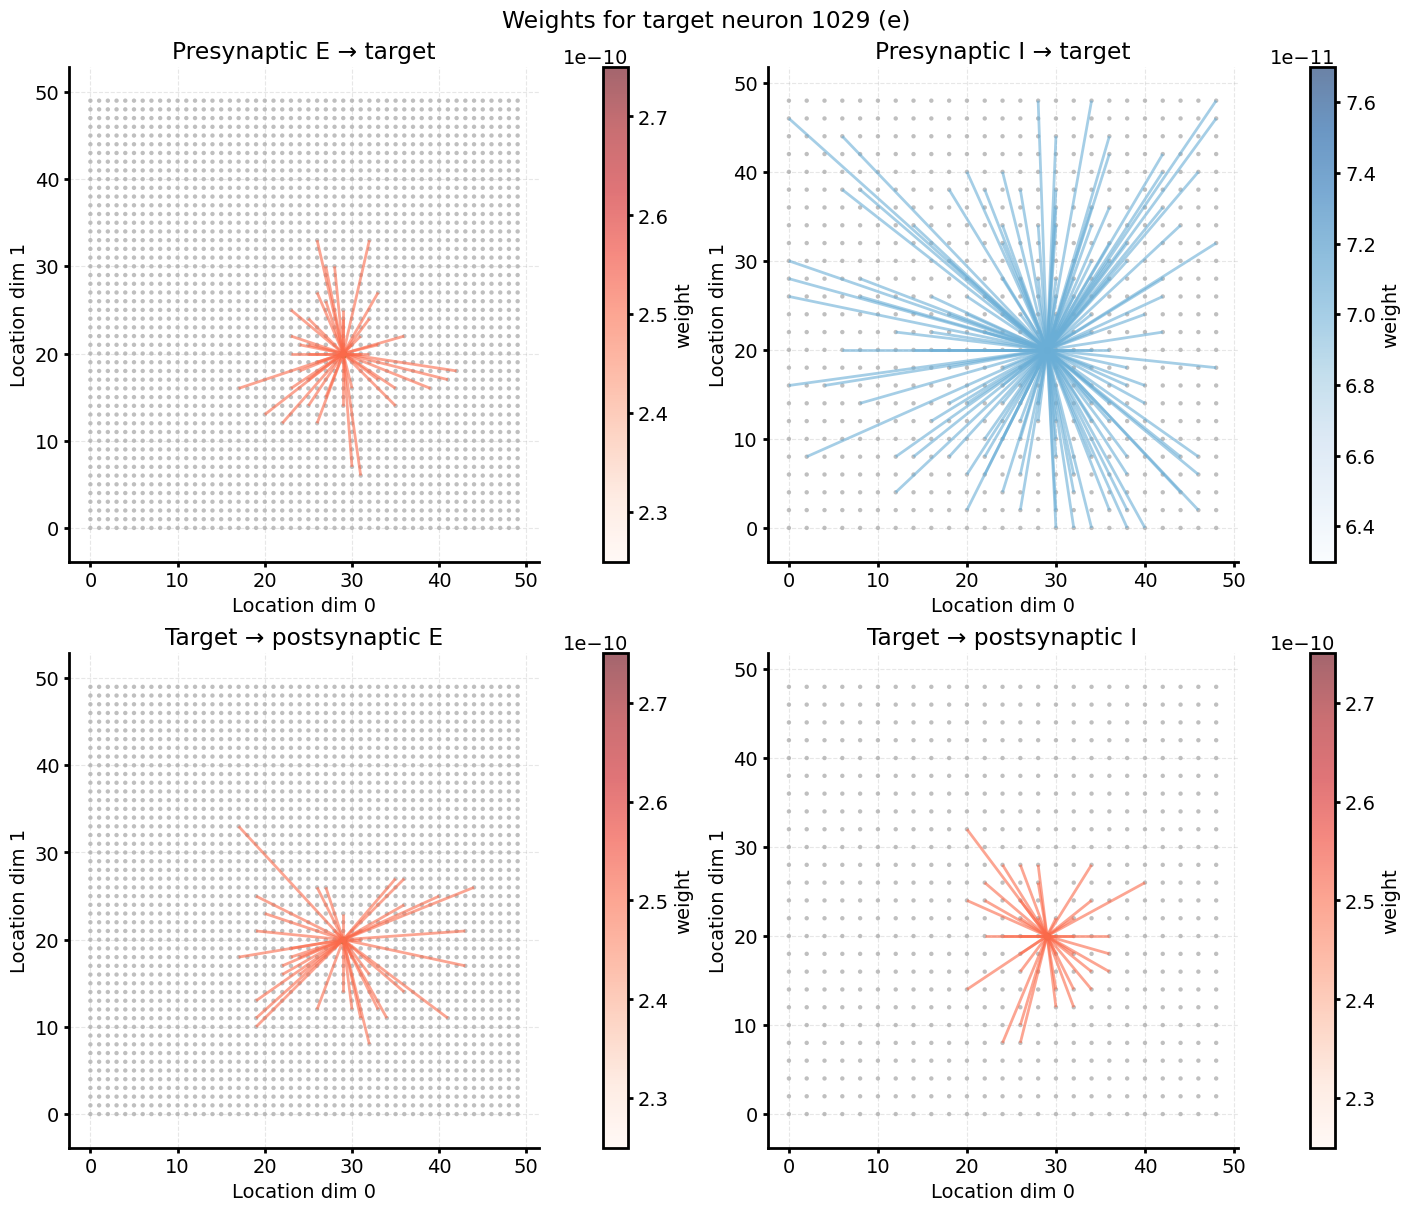

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()

plot_configs = []
for title, weights, source_locations in incoming:
    segments, weight_values = weight_utils.build_segments_incoming(
        weights, TARGET_NEURON_ID, source_locations, target_location
    )
    if weight_values.size == 0:
        print(f'Warning: no non-zero incoming weights for {title}.')
    is_inhibitory_source = source_locations is group_i_location_by_id
    colormap = plt.cm.Blues if is_inhibitory_source else plt.cm.Reds
    plot_configs.append((title, segments, weight_values, source_locations, colormap))

for title, weights, post_locations in outgoing:
    segments, weight_values = weight_utils.build_segments_outgoing(
        weights, TARGET_NEURON_ID, target_location, post_locations
    )
    if weight_values.size == 0:
        print(f'Warning: no non-zero outgoing weights for {title}.')
    is_inhibitory_source = target_group == 'i'
    colormap = plt.cm.Blues if is_inhibitory_source else plt.cm.Reds
    plot_configs.append((title, segments, weight_values, post_locations, colormap))

for ax, (title, segments, weight_values, location_map, colormap) in zip(
    axes, plot_configs
):
    if location_map is group_e_location_by_id:
        locations = group_e_neuron_locations
    else:
        locations = group_i_neuron_locations
    plot_connections(
        ax, title, segments, weight_values, locations, target_location, colormap
    )
    print(f"Number of connections for {title}: ", len(segments))

fig.suptitle(f'Weights for target neuron {TARGET_NEURON_ID} ({target_group})')
plt.savefig(BURYNOUTPUTS_DIR+f'/plots/neuron_{target_group}{TARGET_NEURON_ID}_weight_lines.png')
plt.show()

In [47]:

selected_neuron_locations = []
for neuron_id in SELECTED_NEURON_IDS:
    if neuron_id in group_e_neuron_ids:
        idx = np.where(group_e_neuron_ids == neuron_id)[0][0]
        selected_neuron_locations.append(group_e_neuron_locations[idx])
        

In [48]:
def plot_weight_dots(
    ax, title, weight_locations, weight_values, neuron_locations, target_location, colormap
):
    ax.scatter(
        neuron_locations[:, 0],
        neuron_locations[:, 1],
        color='gray',
        s=10,
        alpha=0.5,
        edgecolors='none',
    )

    if weight_values.size:
        weight_magnitudes = np.abs(weight_values)
        weight_norm = Normalize(
            vmin=weight_magnitudes.min(), vmax=weight_magnitudes.max()
        )
        scatter = ax.scatter(
            weight_locations[:, 0],
            weight_locations[:, 1],
            c=weight_values,
            cmap=colormap,
            norm=weight_norm,
            s=20,
            edgecolors='none',
        )
        plt.colorbar(scatter, ax=ax, label='weight')

    ax.set_title(title)
    ax.set_xlabel('Location dim 0')
    ax.set_ylabel('Location dim 1')
    ax.axis('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.scatter(
        target_location[0],
        target_location[1],
        color='green',
        s=50,
        alpha=0.3,
        label=f'Target neuron {TARGET_NEURON_ID} ({target_group})',
    )
    ax.scatter(
        [loc[0] for loc in selected_neuron_locations],
        [loc[1] for loc in selected_neuron_locations],
        c="gold",
        s=50,
        marker="o",
        alpha=0.3,
        label="Selected Stimulated Neurons",
    )


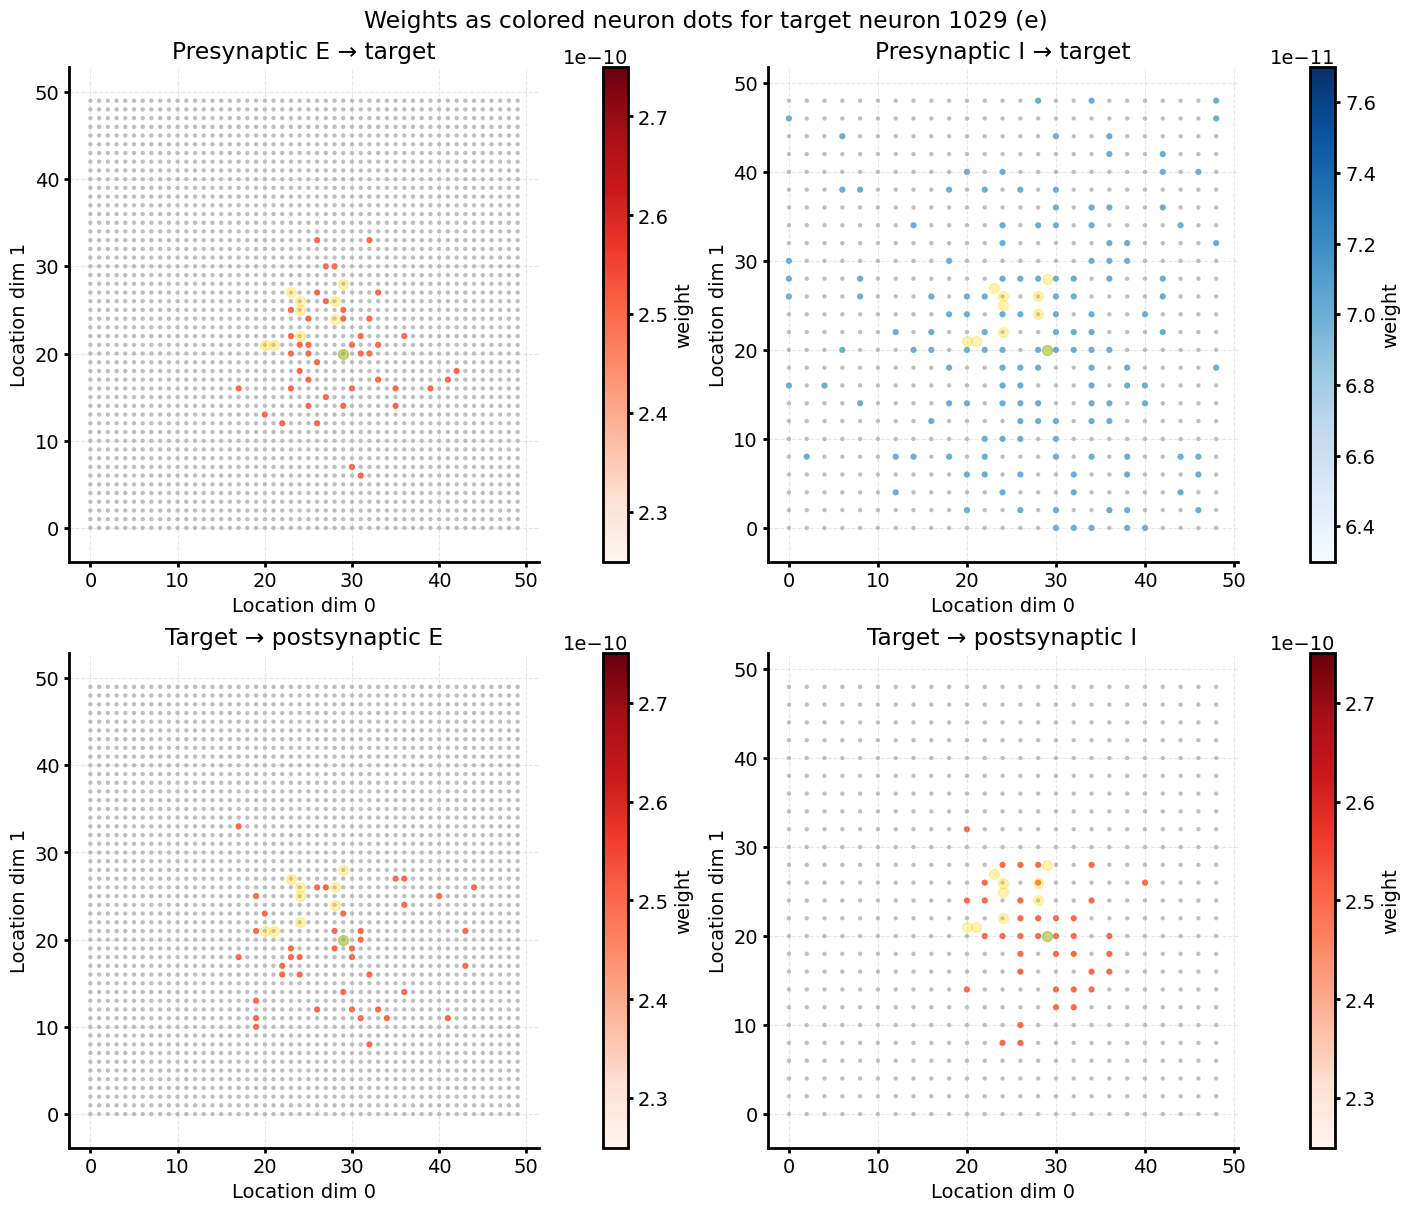

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()

dot_plot_configs = []
for title, weights, source_locations in incoming:
    locations, weight_values = weight_utils.build_weighted_locations_incoming(
        weights, TARGET_NEURON_ID, source_locations
    )
    if weight_values.size == 0:
        print(f'Warning: no non-zero incoming weights for {title}.')
    is_inhibitory_source = source_locations is group_i_location_by_id
    colormap = plt.cm.Blues if is_inhibitory_source else plt.cm.Reds
    dot_plot_configs.append((title, locations, weight_values, source_locations, colormap))

for title, weights, post_locations in outgoing:
    locations, weight_values = weight_utils.build_weighted_locations_outgoing(
        weights, TARGET_NEURON_ID, post_locations
    )
    if weight_values.size == 0:
        print(f'Warning: no non-zero outgoing weights for {title}.')
    is_inhibitory_source = target_group == 'i'
    colormap = plt.cm.Blues if is_inhibitory_source else plt.cm.Reds
    dot_plot_configs.append((title, locations, weight_values, post_locations, colormap))

for ax, (title, locations, weight_values, location_map, colormap) in zip(
    axes, dot_plot_configs
):
    if location_map is group_e_location_by_id:
        all_locations = group_e_neuron_locations
    else:
        all_locations = group_i_neuron_locations
    if locations.size == 0:
        locations = np.empty((0, 2))
    plot_weight_dots(
        ax, title, locations, weight_values, all_locations, target_location, colormap
    )

fig.suptitle(
    f'Weights as colored neuron dots for target neuron {TARGET_NEURON_ID} ({target_group})'
)
plt.savefig(BURYNOUTPUTS_DIR+f'/plots/neuron_{target_group}{TARGET_NEURON_ID}_weight_dots.png')
plt.show()